# Multinomial logistic probes for character count

This notebook collects **residual-stream activations after layer 1**, specifically from TransformerLens hook `blocks.1.hook_resid_post`, and fits a multinomial logistic-regression classifier for character counts 1 through 107. A multinomial linear classifier has one learned logit (one probe) per class, so the 107 rows of `coef_` are the 107 character-count probes.

Count 0 is excluded because it is the special BOS/newline state, not a positive character count. The final heatmap shows the mean probe logit for every `(true character count, probe index)` pair. Red means a higher mean activation and blue means a lower mean activation; the colorbar gives the numerical scale.

In [83]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import project_main.checkpoints as project_checkpoints
import project_main.data as project_data
import project_main.model as project_model
import project_main.tokens as project_tokens

# Experiment settings
RUN_DIR = Path("../results/line_breaks_results")
CHECKPOINT_PATH = RUN_DIR / "checkpoints" / "final.pt"
# Fixed probing site: the residual stream immediately after layer 1.
PROBE_ACTIVATION_SITE = "blocks.0.hook_resid_pre"
N_TRAIN_SEQUENCES = 2_000
N_EVAL_SEQUENCES = 1_000
COLLECTION_BATCH_SIZE = 128
TRAIN_SEED = 17_290
EVAL_SEED = 17_291

# Positive line lengths are exactly 1, ..., 107 for this task.
PROBE_COUNTS = np.arange(1, 108)
N_PROBES = len(PROBE_COUNTS)
assert N_PROBES == 107

In [84]:
with open(RUN_DIR / "config.json", "r") as f:
    cfg = json.load(f)

device = "cuda" if torch.cuda.is_available() else "cpu"
vocab = project_tokens.build_vocab(cfg["task"])
model = project_model.build_model(cfg=cfg, device=device)
checkpoint = project_checkpoints.load_checkpoint(
    path=CHECKPOINT_PATH,
    model=model,
    map_location=device,
)
model.eval()

print(f"Loaded checkpoint step {checkpoint['step']} on {device}")
print(f"Probing residual stream after layer 1: {PROBE_ACTIVATION_SITE}")

Building vocab...
('BOS', 'NEWLINE')
Loaded checkpoint step 10000 on cpu
Probing residual stream after layer 1: blocks.0.hook_resid_pre


In [85]:
def character_counts_for_tokens(token_rows: torch.Tensor) -> torch.Tensor:
    """Return the running line length at every token position."""
    all_counts = []

    for token_row in token_rows.detach().cpu().tolist():
        running_count = 0
        row_counts = []

        for token_id in token_row:
            if token_id == vocab.newline_id:
                running_count = 0
            else:
                token_name = vocab.decode_token(token_id)
                running_count += project_data.extract_character_count(token_name)
            row_counts.append(running_count)

        all_counts.append(row_counts)

    return torch.tensor(all_counts, dtype=torch.long)


@torch.no_grad()
def collect_probe_dataset(
    n_sequences: int,
    *,
    seed: int,
    batch_size: int = COLLECTION_BATCH_SIZE,
) -> tuple[np.ndarray, np.ndarray]:
    """Collect residual vectors and their positive character-count labels."""
    activation_chunks = []
    count_chunks = []

    for start in range(0, n_sequences, batch_size):
        this_batch_size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(
            batch_size=this_batch_size,
            vocab=vocab,
            task_cfg=cfg["task"],
            device=device,
            seed=seed + start,
        )
        counts = character_counts_for_tokens(batch.tokens)
        saved = {}

        def save_residuals(activation, hook):
            saved["residuals"] = activation.detach().cpu()

        model.run_with_hooks(
            batch.tokens,
            prepend_bos=False,
            fwd_hooks=[
                (PROBE_ACTIVATION_SITE, save_residuals),
            ],
        )

        residuals = saved["residuals"]
        keep = counts > 0  # Drop BOS and newline positions (count 0).
        activation_chunks.append(residuals[keep].float().numpy())
        count_chunks.append(counts[keep].numpy())

    X = np.concatenate(activation_chunks, axis=0)
    y = np.concatenate(count_chunks, axis=0)
    return X, y

In [86]:
X_train, y_train = collect_probe_dataset(
    N_TRAIN_SEQUENCES,
    seed=TRAIN_SEED,
)
X_eval, y_eval = collect_probe_dataset(
    N_EVAL_SEQUENCES,
    seed=EVAL_SEED,
)

missing_train_counts = sorted(set(PROBE_COUNTS) - set(np.unique(y_train)))
if missing_train_counts:
    raise RuntimeError(
        f"Training data is missing counts {missing_train_counts}. "
        "Increase N_TRAIN_SEQUENCES."
    )

print("Train:", X_train.shape, y_train.shape)
print("Eval: ", X_eval.shape, y_eval.shape)
print(f"Observed character counts: {y_train.min()} through {y_train.max()}")

Train: (94531, 128) (94531,)
Eval:  (47283, 128) (47283,)
Observed character counts: 1 through 107


## Fit the 107 probes jointly

`LogisticRegression` uses multinomial cross-entropy for this multiclass problem. Standardizing each residual dimension makes the regularization strength comparable across dimensions. The classifier learns a weight vector and intercept for every count; these 107 class logits are the probe activations visualized below.

In [87]:
probe_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=1_000,
        tol=1e-3,
    ),
)
probe_model.fit(X_train, y_train)

logistic_regression = probe_model.named_steps["logisticregression"]
assert np.array_equal(logistic_regression.classes_, PROBE_COUNTS)
assert logistic_regression.coef_.shape[0] == N_PROBES

eval_predictions = probe_model.predict(X_eval)
eval_accuracy = accuracy_score(y_eval, eval_predictions)
eval_mae = np.mean(np.abs(eval_predictions - y_eval))
eval_rmse = np.sqrt(np.mean((eval_predictions - y_eval) ** 2))

print(f"Exact-count evaluation accuracy: {eval_accuracy:.2%}")
print(f"Mean absolute count error: {eval_mae:.3f}")
print(f"Root mean square count error: {eval_rmse:.3f}")
print("Probe weight matrix:", logistic_regression.coef_.shape)

Exact-count evaluation accuracy: 7.99%
Mean absolute count error: 17.482
Root mean square count error: 31.334
Probe weight matrix: (107, 128)


In [88]:
# Collect both the 107 pre-softmax class logits and the corresponding softmax
# probabilities for every evaluation token.
eval_probe_activations = probe_model.decision_function(X_eval)
eval_probe_probabilities = probe_model.predict_proba(X_eval)
assert eval_probe_activations.shape == (len(y_eval), N_PROBES)
assert eval_probe_probabilities.shape == (len(y_eval), N_PROBES)

activation_sums = np.zeros((N_PROBES, N_PROBES), dtype=np.float64)
probability_sums = np.zeros((N_PROBES, N_PROBES), dtype=np.float64)
np.add.at(activation_sums, y_eval - 1, eval_probe_activations)
np.add.at(probability_sums, y_eval - 1, eval_probe_probabilities)
examples_per_true_count = np.bincount(y_eval, minlength=N_PROBES + 1)[1:]

if np.any(examples_per_true_count == 0):
    missing_eval_counts = PROBE_COUNTS[examples_per_true_count == 0].tolist()
    raise RuntimeError(
        f"Evaluation data is missing counts {missing_eval_counts}. "
        "Increase N_EVAL_SEQUENCES."
    )

mean_probe_activation = activation_sums / examples_per_true_count[:, None]
row_centered_mean_probe_activation = (
    mean_probe_activation - mean_probe_activation.mean(axis=1, keepdims=True)
)

# Average per-token probabilities within each true-count group. This is not
# the same as applying softmax to the mean logits.
mean_probe_probability = probability_sums / examples_per_true_count[:, None]

print("Row-centered mean-logit matrix:", row_centered_mean_probe_activation.shape)
print("Mean softmax-probability matrix:", mean_probe_probability.shape)
print("Probability row sums:", mean_probe_probability.sum(axis=1).min(), "to", mean_probe_probability.sum(axis=1).max())

Row-centered mean-logit matrix: (107, 107)
Mean softmax-probability matrix: (107, 107)
Probability row sums: 0.9999999839397123 to 1.00000002303192


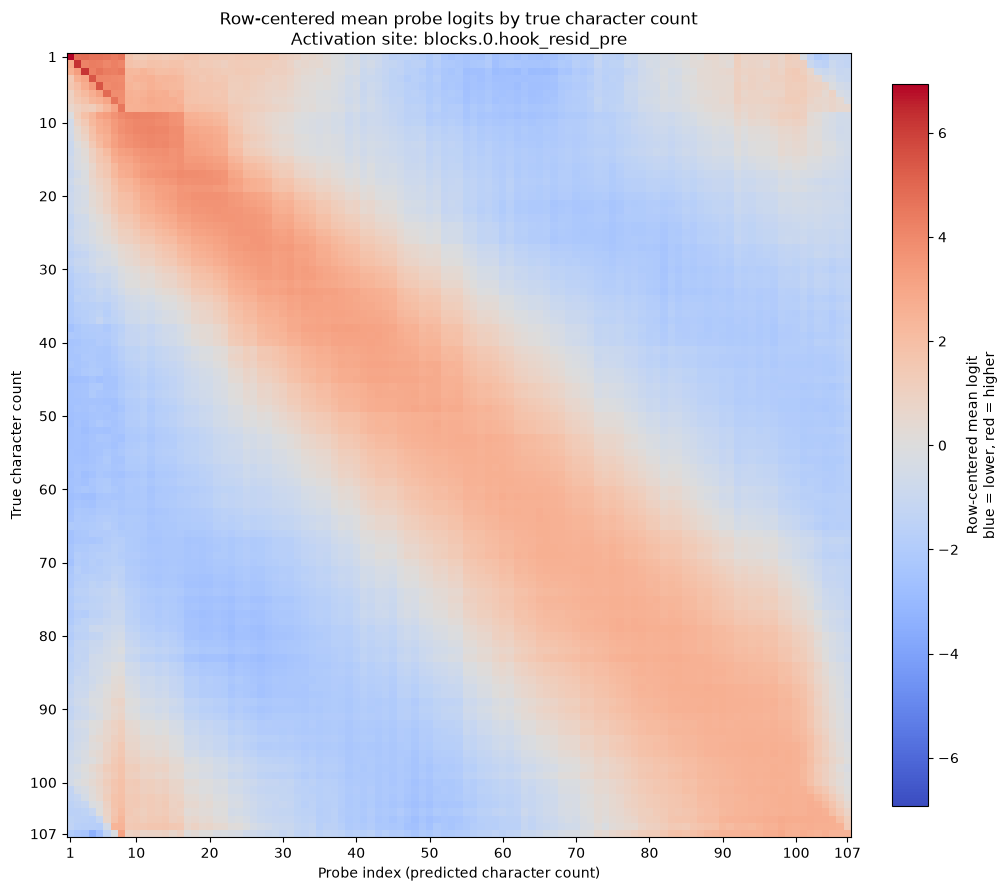

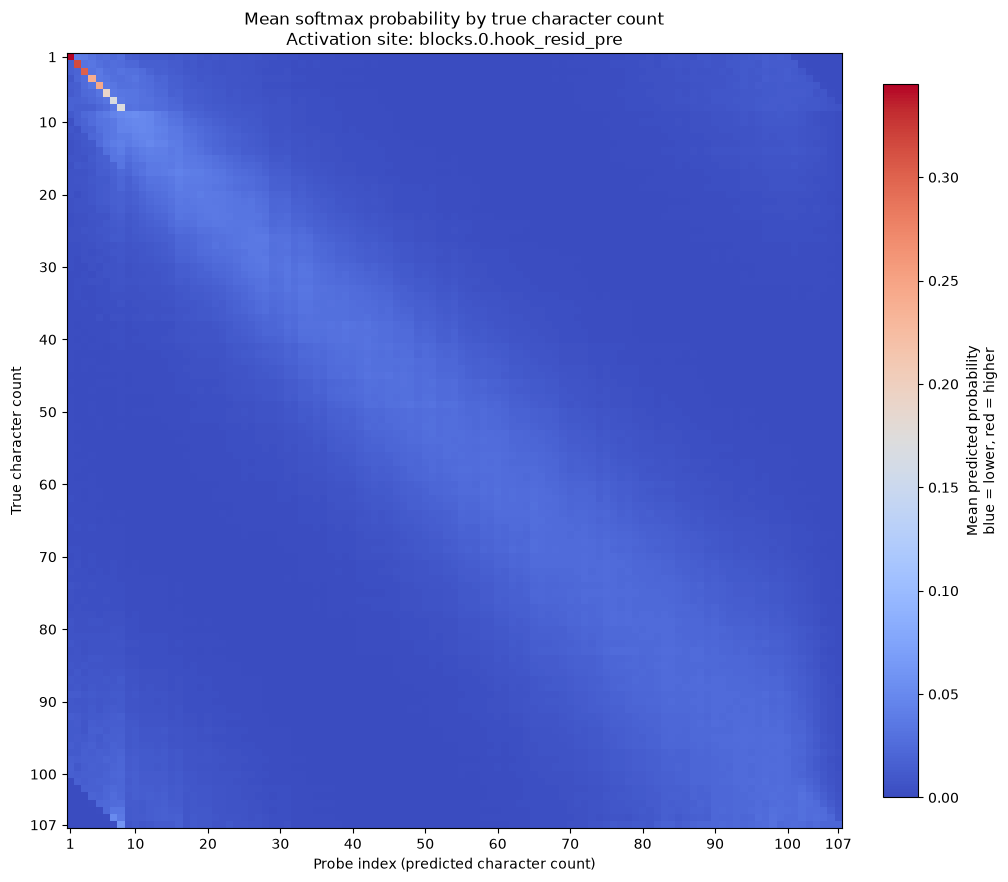

In [89]:
tick_values = np.r_[1, np.arange(10, 101, 10), 107]

fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
logit_limit = max(float(np.abs(row_centered_mean_probe_activation).max()), 1e-12)
logit_norm = TwoSlopeNorm(vmin=-logit_limit, vcenter=0.0, vmax=logit_limit)
logit_image = ax.imshow(
    row_centered_mean_probe_activation,
    cmap="coolwarm",
    norm=logit_norm,
    origin="upper",
    interpolation="nearest",
    extent=(0.5, 107.5, 107.5, 0.5),
    aspect="equal",
)
ax.set_xticks(tick_values)
ax.set_yticks(tick_values)
ax.set_xlabel("Probe index (predicted character count)")
ax.set_ylabel("True character count")
ax.set_title(
    "Row-centered mean probe logits by true character count\n"
    f"Activation site: {PROBE_ACTIVATION_SITE}"
)
colorbar = fig.colorbar(logit_image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Row-centered mean logit\nblue = lower, red = higher")
plt.show()

fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
probability_image = ax.imshow(
    mean_probe_probability,
    cmap="coolwarm",
    vmin=0.0,
    vmax=max(float(mean_probe_probability.max()), 1e-12),
    origin="upper",
    interpolation="nearest",
    extent=(0.5, 107.5, 107.5, 0.5),
    aspect="equal",
)
ax.set_xticks(tick_values)
ax.set_yticks(tick_values)
ax.set_xlabel("Probe index (predicted character count)")
ax.set_ylabel("True character count")
ax.set_title(
    "Mean softmax probability by true character count\n"
    f"Activation site: {PROBE_ACTIVATION_SITE}"
)
colorbar = fig.colorbar(probability_image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Mean predicted probability\nblue = lower, red = higher")
plt.show()

## Cosine-similarity structure

The first matrix compares the directions learned by the 107 probes. Because the classifier was fit after standardization, its coefficients are divided by the fitted feature scales before comparison; this maps every probe direction back into the original `blocks.1.hook_resid_post` coordinate system. The global mean probe vector is then subtracted from every probe vector.

The second matrix compares the mean residual-stream vector for every true character count at that same activation site. Before comparison, the global mean residual-stream activation across all evaluation tokens is subtracted from every character-count mean. Both plots therefore show cosine similarity after global-mean centering and use the full range from −1 (blue) through 0 (white) to +1 (red).

In [90]:
def row_cosine_similarity(vectors: np.ndarray) -> np.ndarray:
    """Pairwise cosine similarities between the rows of a 2D array."""
    row_norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    if np.any(row_norms == 0):
        raise ValueError("Cannot compute cosine similarity for a zero vector.")
    normalized = vectors / row_norms
    return np.clip(normalized @ normalized.T, -1.0, 1.0)


# Convert weights from standardized-feature coordinates back to the original
# residual-stream basis: w_original = w_standardized / feature_scale.
standardizer = probe_model.named_steps["standardscaler"]
probe_vectors = logistic_regression.coef_ / standardizer.scale_[None, :]
global_mean_probe_vector = probe_vectors.mean(axis=0, keepdims=True)
centered_probe_vectors = probe_vectors - global_mean_probe_vector
probe_vector_cosine_similarity = row_cosine_similarity(centered_probe_vectors)

# Average the layer-1 residual-stream vectors within each true-count group.
residual_sums = np.zeros((N_PROBES, X_eval.shape[1]), dtype=np.float64)
np.add.at(residual_sums, y_eval - 1, X_eval)
mean_residual_by_count = residual_sums / examples_per_true_count[:, None]
global_mean_residual = X_eval.mean(axis=0, keepdims=True)
centered_mean_residual_by_count = mean_residual_by_count - global_mean_residual
mean_residual_cosine_similarity = row_cosine_similarity(
    centered_mean_residual_by_count
)

print("Global residual mean:", global_mean_residual.shape)
print("Global probe-vector mean:", global_mean_probe_vector.shape)
print("Probe-vector cosine matrix:", probe_vector_cosine_similarity.shape)
print("Mean-residual cosine matrix:", mean_residual_cosine_similarity.shape)

Global residual mean: (1, 128)
Global probe-vector mean: (1, 128)
Probe-vector cosine matrix: (107, 107)
Mean-residual cosine matrix: (107, 107)


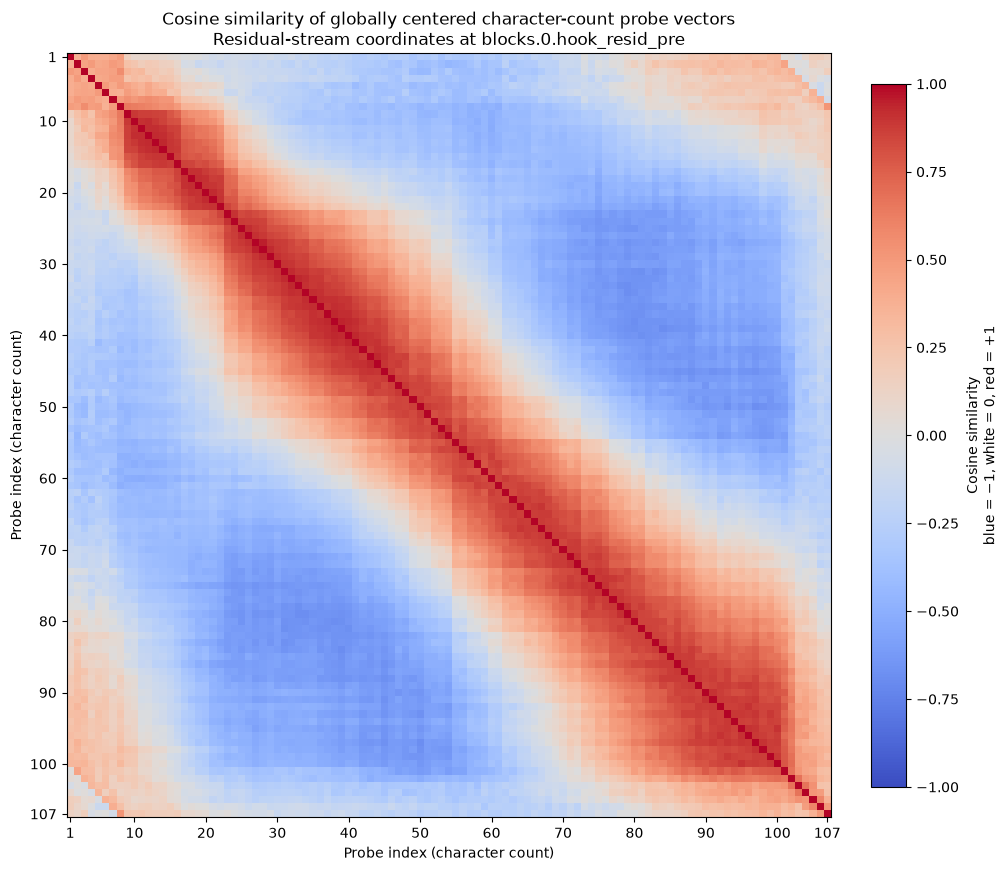

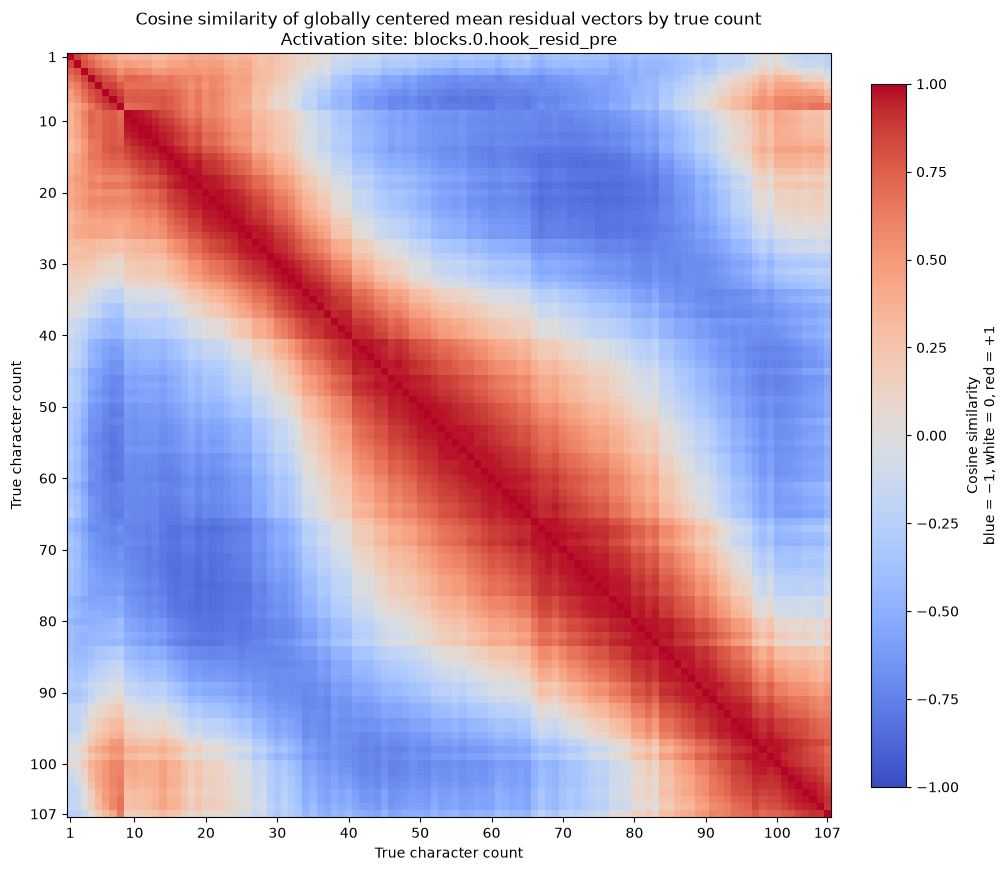

In [91]:
def plot_cosine_similarity_matrix(
    similarity_matrix: np.ndarray,
    *,
    title: str,
    axis_label: str,
) -> None:
    fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
    image = ax.imshow(
        similarity_matrix,
        cmap="coolwarm",
        vmin=-1.0,
        vmax=1.0,
        origin="upper",
        interpolation="nearest",
        extent=(0.5, 107.5, 107.5, 0.5),
        aspect="equal",
    )
    ax.set_xticks(tick_values)
    ax.set_yticks(tick_values)
    ax.set_xlabel(axis_label)
    ax.set_ylabel(axis_label)
    ax.set_title(title)
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label("Cosine similarity\nblue = −1, white = 0, red = +1")
    plt.show()


plot_cosine_similarity_matrix(
    probe_vector_cosine_similarity,
    title=(
        "Cosine similarity of globally centered character-count probe vectors\n"
        f"Residual-stream coordinates at {PROBE_ACTIVATION_SITE}"
    ),
    axis_label="Probe index (character count)",
)

plot_cosine_similarity_matrix(
    mean_residual_cosine_similarity,
    title=(
        "Cosine similarity of globally centered mean residual vectors by true count\n"
        f"Activation site: {PROBE_ACTIVATION_SITE}"
    ),
    axis_label="True character count",
)